# Plasma Spectroscopy Analysis

This notebook analyses a simple simulated emission spectrum. The objective is not to produce publishable plasma diagnostics; the objective is to show a clean, reproducible workflow using Python, Jupyter, SciPy, Matplotlib and a short physics interpretation.

Main steps:
1. Load a spectrum.
2. Apply a simple offset correction to the spectrum.
3. Fit Gaussian profiles to known emission lines.
4. Extract peak position, width, area and an approximate wavelength/velocity shift.
5. Estimate photon energies from the fitted line centres.


### Why synthetic data?

I use synthetic data because this project is intended as a first reproducible workflow, not as a final experimental analysis. Working with simulated data makes it easier to understand each step: loading the spectrum, detecting lines, fitting Gaussian profiles and interpreting the fitted parameters.

The same structure could later be applied to real experimental or public spectral data.

## 1. Imports

In [29]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from fitting import fit_line, fits_to_dataframe
from plotting import plot_fit, plot_residuals

## 2. Load the spectrum

The file `sample_spectrum.csv` contains two columns:

- `wavelength_nm`: wavelength in nanometres.
- `intensity`: arbitrary intensity units.


In [6]:
csv_path = PROJECT_ROOT / "sample_spectrum.csv"

df = pd.read_csv(csv_path)
df["intensity_corrected"] = df["intensity"] - df["intensity"].min()
df.head()

,wavelength_nm,intensity,intensity_corrected
0,420.00000,0.227618,0.055736
1,420.10004,0.194165,0.022283
2,420.20008,0.239090,0.067208
3,420.30012,0.244007,0.072126
4,420.40016,0.171882,0.000000


## 3. Simple baseline correction

For this introductory project, I apply a very simple baseline correction by subtracting the minimum intensity value from the spectrum. This sets the lowest intensity level close to zero and makes the emission peaks easier to fit.

This is not a complete background subtraction method, but it is enough for this synthetic dataset.

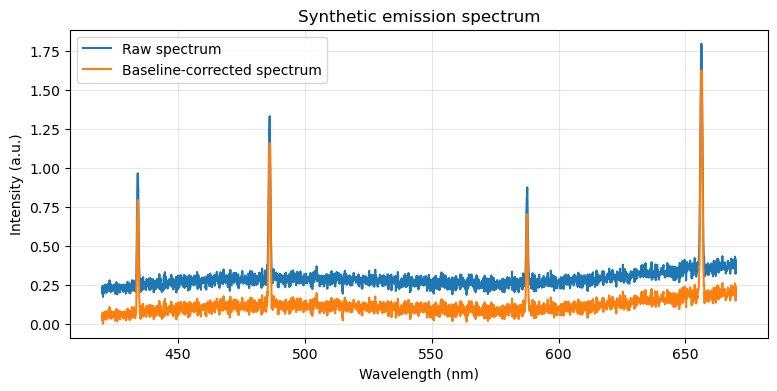

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(df["wavelength_nm"], df["intensity"], label="Raw spectrum")
ax.plot(df["wavelength_nm"], df["intensity_corrected"], label="Baseline-corrected spectrum")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Intensity (a.u.)")
ax.set_title("Synthetic emission spectrum")
ax.legend()
ax.grid(True, alpha=0.3)

baseline_path = PROJECT_ROOT / "figures" / "spectrum_baseline.png"
baseline_path.parent.mkdir(parents=True, exist_ok=True)

fig.savefig(baseline_path, dpi=300, bbox_inches="tight")
plt.show()

**Figure 1.** Synthetic emission spectrum used in this project. The blue curve shows the raw spectrum, while the orange curve shows the spectrum after a simple offset correction obtained by subtracting the minimum intensity value. This correction shifts the lowest intensity level close to zero while preserving the overall spectral structure.

## 4. Gaussian fitting

In this simplified model, each isolated emission line is fitted with a Gaussian profile. This is a common first approximation for spectral peaks, especially when the goal is to extract basic parameters such as the central wavelength, width and area.

This does not mean that all real spectral lines are exactly Gaussian. In real plasma spectroscopy, other profiles such as Lorentzian or Voigt profiles may be more appropriate depending on the broadening mechanisms.

An isolated emission line is approximated with a Gaussian profile:

$$I(\lambda)=A\exp\left[-\frac{1}{2}\left(\frac{\lambda-\lambda_0}{\sigma}\right)^2\right]+C.$$

From this fit we extract:

- line centre $\lambda_0$,
- full width at half maximum, $\mathrm{FWHM}=2\sqrt{2\ln 2}\,\sigma$,
- integrated line area,
- Doppler velocity shift.


#### Photon energy estimation

The fitted central wavelength of each spectral line can be converted into photon energy using:

$$
E = \frac{hc}{\lambda}
$$

Using $hc = 1239.84 $, $\mathrm{eV\,nm}$, the photon energy in electronvolts is obtained from:

$$
E(\mathrm{eV}) = \frac{1239.84}{\lambda(\mathrm{nm})}
$$

This connects the fitted spectral line positions with the energy scale of the corresponding radiative transitions.

In [12]:
def photon_energy_ev(wavelength_nm):
    """
    Convert wavelength in nanometres to photon energy in electronvolts.

    E(eV) = hc / lambda
    with hc = 1239.841984 eV·nm
    """
    HC_EV_NM = 1239.841984
    return HC_EV_NM / wavelength_nm

In [13]:
known_lines = {
    'H-gamma': 434.05,
    'H-beta': 486.13,
    'He I': 587.56,
    'H-alpha': 656.28,
}

fits = []
fitted_windows = []

for name, expected_center in known_lines.items():
    fit, window = fit_line(df, name, expected_center, window_nm=3.0)
    fits.append(fit)
    fitted_windows.append(window)

results = fits_to_dataframe(fits)

results["photon_energy_eV"] = [
    photon_energy_ev(x) for x in results["center_nm"]
]

results

,line_name,center_nm,amplitude,sigma_nm,offset,fwhm_nm,area,velocity_shift_kms,photon_energy_eV
0,H-gamma,434.113880,0.747154,0.286389,0.067777,0.674395,0.536360,44.120775,2.856029
1,H-beta,486.072821,1.038252,0.336571,0.120958,0.792564,0.875930,-35.261942,2.550733
2,He I,587.598678,0.602746,0.300481,0.089948,0.707578,0.453984,19.734564,2.110015
3,H-alpha,656.311623,1.475577,0.386988,0.184730,0.911288,1.431363,14.445726,1.889106


## 5. Figures

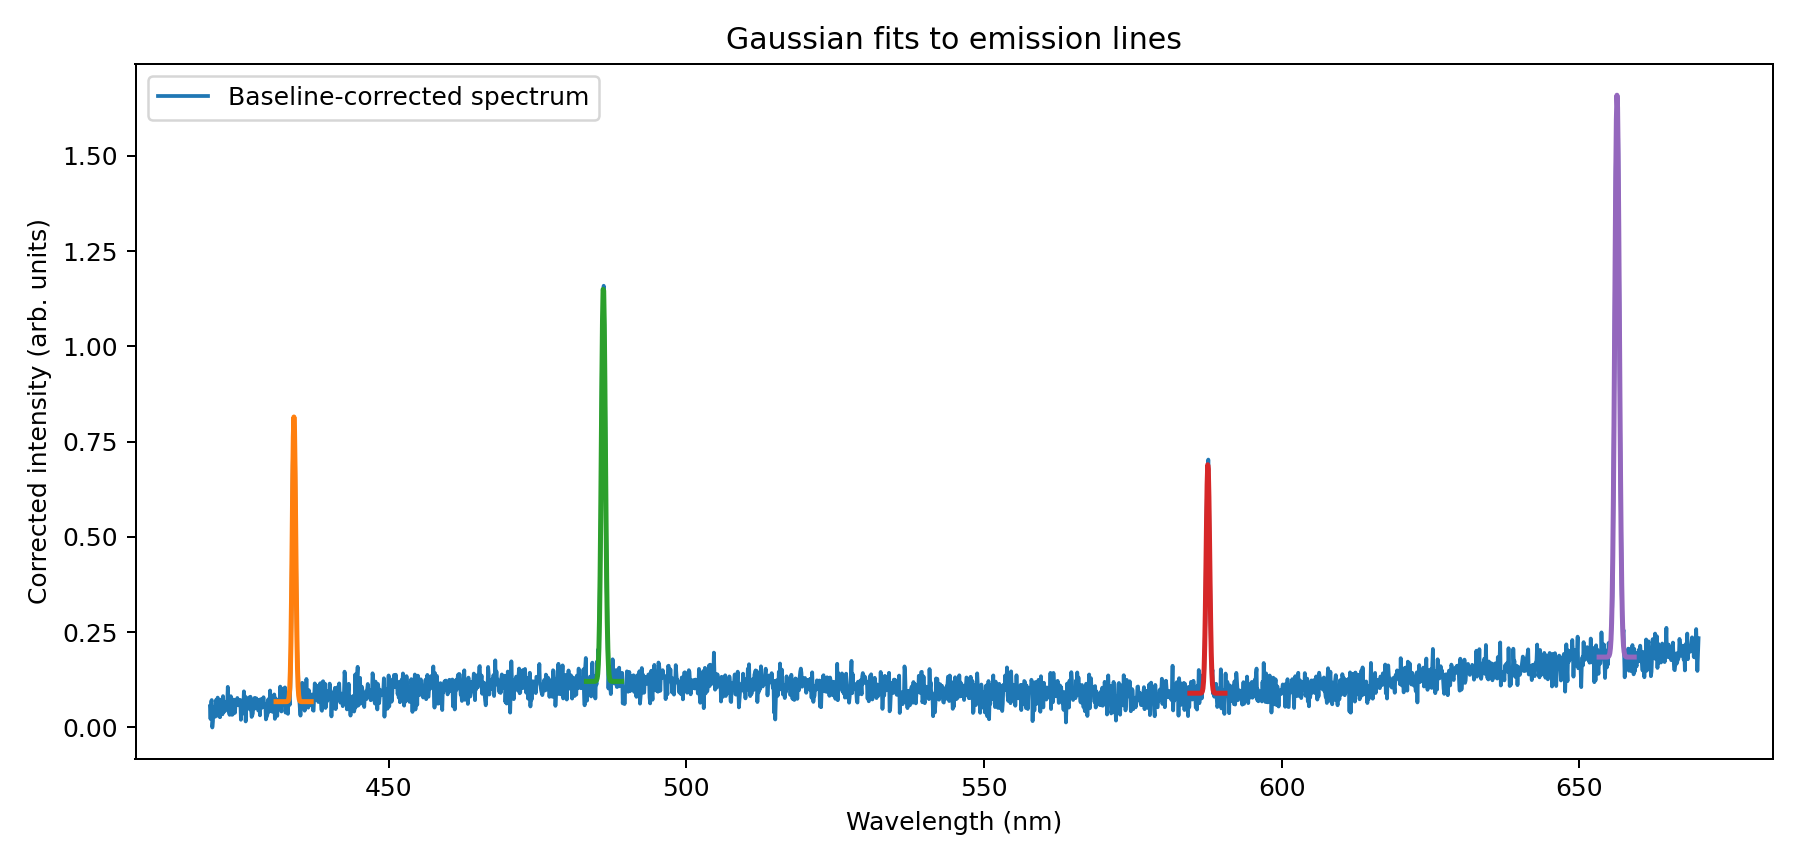

In [15]:
from IPython.display import Image, display

figures_dir = PROJECT_ROOT / "figures"
results_dir = PROJECT_ROOT / "results"

figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

spectrum_path = figures_dir / "spectrum_fit.png"
residuals_path = figures_dir / "residuals.png"

plot_fit(df, fitted_windows, spectrum_path)
plot_residuals(fitted_windows, residuals_path)

results.to_csv(results_dir / "fit_results.csv", index=False)

display(Image(filename=str(spectrum_path)))

**Figure 2.** Gaussian fits to the main emission lines of the synthetic spectrum. Each selected spectral window was fitted independently in order to estimate the line centre, width and integrated intensity.

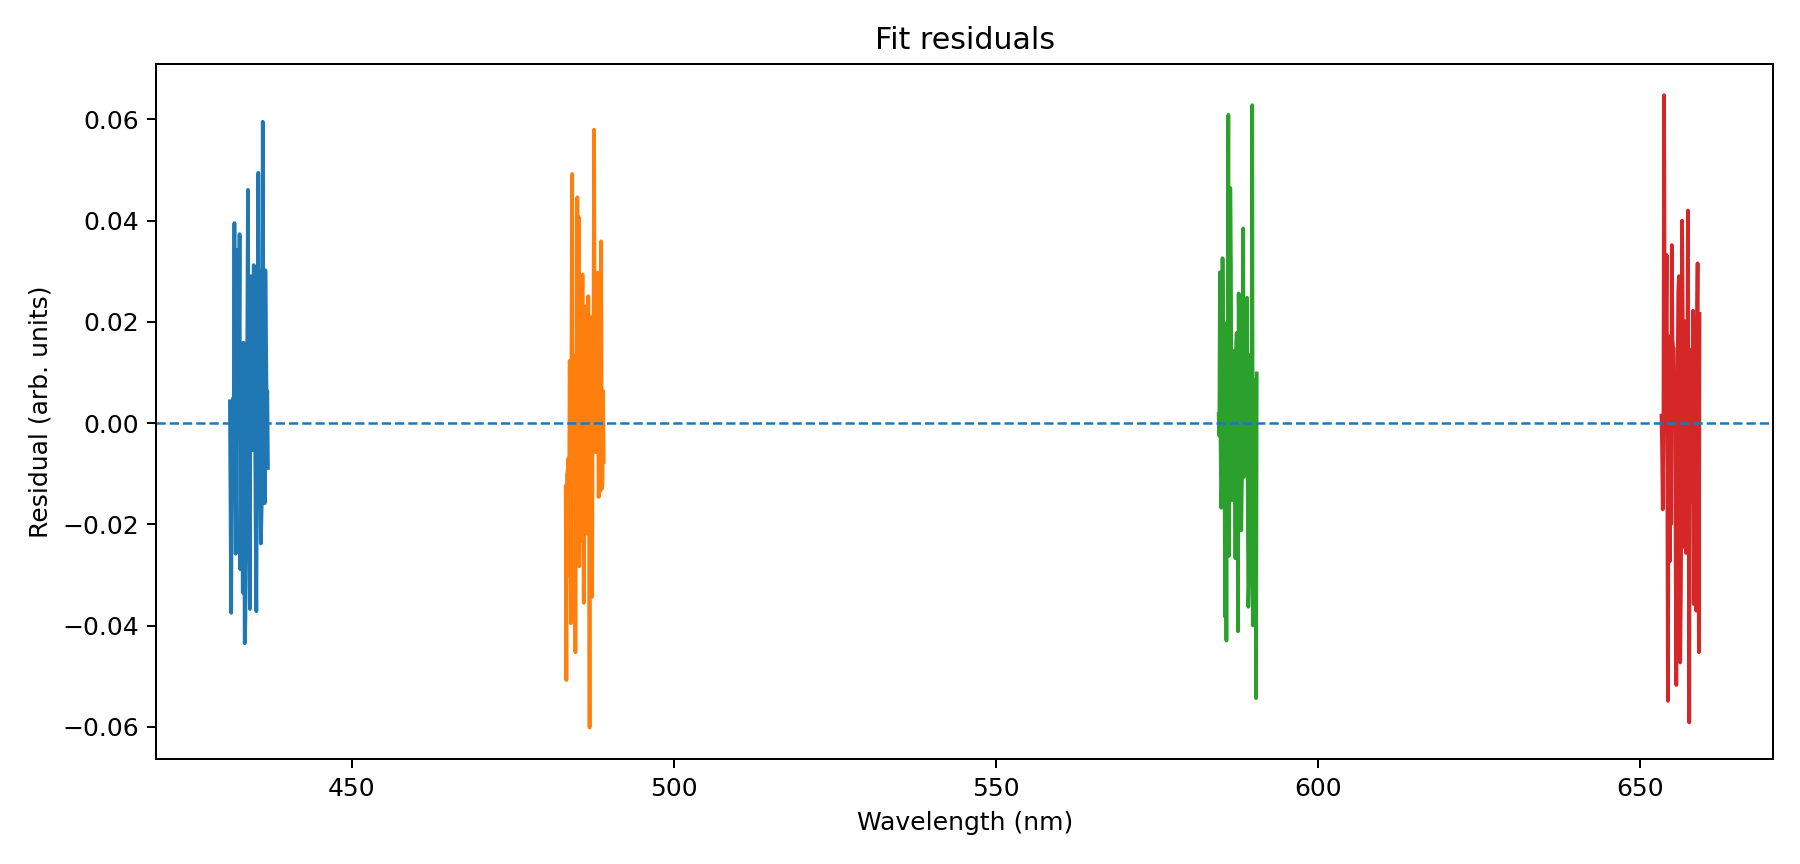

In [17]:
display(Image(filename=str(residuals_path)))

**Figure 3.** Residuals of the Gaussian fits for the selected emission lines. The residuals provide a simple check of how well the Gaussian model reproduces the synthetic spectral data.

## 6. Physical interpretation

The fitted centres are close to the expected wavelengths, so the simulated wavelength calibration is reasonable. Small shifts in the fitted centres could be interpreted as Doppler shifts in a real spectrum, although here they mainly come from the synthetic construction of the dataset and the fitting procedure.

The fitted line widths are reported through the Gaussian width and FWHM. In real spectra, these widths may include Doppler broadening, instrumental broadening, Stark broadening, pressure broadening and unresolved line structure. For that reason, I do not interpret the width as a direct plasma temperature in this introductory version.

Possible extensions:

- Add instrumental broadening correction.
- Compare Gaussian and Voigt profiles.
- Use real spectra from public databases.
- Estimate electron temperature from line ratios with a proper atomic model.


## 7. What I learned

This project helped me practise the basic structure of a scientific Python analysis: loading data, applying a simple preprocessing step, fitting a mathematical model, extracting physical quantities and presenting the results in a reproducible way.

The most useful part for me was connecting the numerical fit parameters with physical ideas such as photon energy, wavelength shifts and spectral line broadening. I also learned that a simple model can be useful as a first step, but that real plasma spectroscopy would require a more careful treatment of noise, calibration and broadening mechanisms.